In [ ]:
from typing import TypedDict,List,Literal,Annotated

In [ ]:
class Data(TypedDict):
  marks: list[float]
  aver_marks:float
  quote:str
  eligibility:str

In [ ]:
from langgraph.graph import StateGraph,START,END

In [ ]:
graph=StateGraph(state_schema=Data)

In [ ]:
from google.colab import userdata
import os
gemini=userdata.get('gemini')
os.environ['GEMINI_API_KEY']=gemini

In [ ]:
pip install langchain_google_genai

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [ ]:
llm1=ChatGoogleGenerativeAI(model="gemini-2.0-flash",temperature=0.6)

In [ ]:
# 1 node average
def average(state:Data):
  return {'aver_marks':sum(state['marks'])/len(state['marks'])}

# 2 best Student

def best(state:Data):
  app= llm1.invoke("Studen scored very good marks in the assessment so please create a quote to motivate and congrulate the student").content
  return {"eligibility":"strongly preffered","quote":app}
# average Student

def moderate(state:Data):
  app= llm1.invoke("Studen scored average marks in the assessment so please create a quote to motivate and congrulate the student").content
  return {"eligibility":"moderately preffered","quote":app}
# worst student
def worst(state:Data):
  app= llm1.invoke("Studen scored very less marks in the assessment so please create a quote to motivate and congrulate the student").content
  return {"eligibility":"Not preffered","quote":app}


In [ ]:
# Condition functions
def condition(state:Data):
  if state['aver_marks']>=80:
    return 'best'
  elif state['aver_marks']>=50 and state['aver_marks']<80:
    return 'moderate'
  else:
    return 'worst'

In [ ]:
graph.add_node('average',average)
graph.add_node('best',best)
graph.add_node('moderate',moderate)
graph.add_node('worst',worst)

In [ ]:
graph.add_edge(START,'average')
graph.add_conditional_edges('average',condition,{"best":"best","moderate":"moderate","worst":"worst"})
graph.add_edge('best',END)
graph.add_edge('moderate',END)
graph.add_edge('worst',END)



In [ ]:
flow=graph.compile()

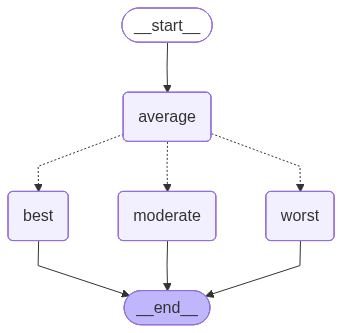

In [ ]:
flow

In [ ]:
flow.invoke({'marks':[80,10,11,0]})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\nPlease retry in 35.871157384s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [ ]:
class QuadraticEquation(TypedDict):
    a: int
    b: int
    c: int
    equation:str
    discriminant:int
    result:str

In [ ]:
def show_equation(state:QuadraticEquation):
  equation=f'{state["a"]}x^2+{state["b"]}x+{state["c"]}'
  return {'equation':equation}
def calculate_discriminant(state:QuadraticEquation):
  discriminant=state["b"]**2-4*state["a"]*state["c"]
  return {'discriminant':discriminant}

In [ ]:
def real_roots(state:QuadraticEquation):
  root1=(-state["b"]+state["discriminant"]**0.5)/(2*state["a"])
  root2=(-state["b"]-state["discriminant"]**0.5)/(2*state["a"])
  result=f'The roots are {root1} and {root2}'
  return {'result':result}

In [ ]:
def repeated_root(state:QuadraticEquation):
  root=-state["b"]/(2*state["a"])
  result=f'The root is {root}'
  return {'result':result}

In [ ]:
def no_real_roots(state:QuadraticEquation):
  result='The equation has no real roots'
  return {'result':result}

In [ ]:
def check_condition(state:QuadraticEquation)-> Literal["real_roots","repeated_roots","no_real_roots"]:
  if state["discriminant"]>0:
    return "real_roots"
  elif state["discriminant"]==0:
    return "repeated_roots"
  else:
    return "no_real_roots"

In [ ]:
from langgraph.graph import StateGraph,START,END

In [ ]:
graph=StateGraph(QuadraticEquation)

In [ ]:
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_root)
graph.add_node('no_real_roots',no_real_roots)
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_real_roots',END)

In [ ]:
workflow=graph.compile()

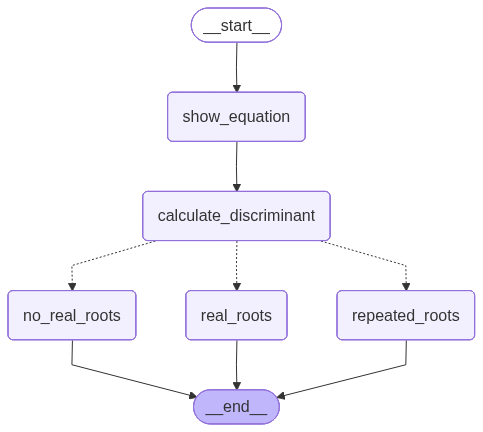

In [ ]:
workflow

In [ ]:
initial_state={'a':1,'b':2,'c':1}

In [ ]:
workflow.invoke(initial_state)

{'a': 1,
 'b': 2,
 'c': 1,
 'equation': '1x^2+2x+1',
 'discriminant': 0,
 'result': 'The root is -1.0'}

In [ ]:
pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 16.6 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.19
    Uninstalling langchain-core-1.2.19:
      Successfully uninstalled langchain-core-1.2.19


In [ ]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,List,Literal,Annotated
from pydantic import BaseModel,Field

In [ ]:
from google.colab import userdata
import os


In [ ]:
openai_key=userdata.get('openai')
os.environ['OPENAI_API_KEY']=openai_key

In [ ]:
model=ChatOpenAI(model_name='gpt-3.5-turbo')

In [ ]:
class SentimentSchema(BaseModel):
  sentiment: Literal['positive','negative']=Field(description='Sentiment of the review')


In [ ]:
structured_model=model.with_structured_output(SentimentSchema)

/usr/local/lib/python3.12/dist-packages/langchain_openai/chat_models/base.py:2210: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [ ]:
prompt='what is the sentiment of the following review - The software too good'
structured_model.invoke(prompt).sentiment

'positive'

In [ ]:
class ReviewState(TypedDict):
  review:str
  sentiment:Literal['positive','negative']
  diagnosis:dict
  response:str

In [ ]:
def find_sentiment(state:ReviewState):
  prompt=f'what is the sentiment of the following review - {state["review"]}'
  sentiment=structured_model.invoke(prompt).sentiment
  return {'sentiment':sentiment}

In [ ]:
def check_sentiment(state:ReviewState)-> Literal["positive_response","run_diagnosis"]:
  if state['sentiment']=='positive':
    return 'positive_response'
  else:
    return "run_diagnosis"

def positive_response(state:ReviewState):
  return {'response':'Thank you for the positive review'}


In [ ]:
graph= StateGraph(ReviewState)

In [ ]:
graph.add_node('find_sentiment',find_sentiment)
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge(START,'find_sentiment')
graph.add_edge('find_sentiment',END)
workflow=graph.compile()

ValueError: Node `find_sentiment` already present.

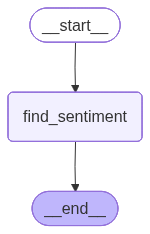

In [ ]:
workflow

In [ ]:
initial_state={'review':'The software too good'}
workflow.invoke(initial_state)

{'review': 'The software too good', 'sentiment': 'positive'}

In [ ]:
# Looping WORKFLOW
from typing import TypedDict
from typing import Annotated
from operator import add

In [ ]:
class Data(TypedDict):
  rn:int
  c:0
  quaote:Annotated[list[str],add]

In [ ]:
graph=StateGraph(state_schema=Data)

In [ ]:
import random

In [ ]:
# random number gen
def rng(state:Data):
  return {"rn":random.randint(0,25)}

def quote(state:Data):
  app=llm1.invoke("create a beautiful quaote")
  return {"quaote":app.content,"c":state["c"]+1}

# Conditional function

def condition1(state:Data):
  if state['rn']>15:
    return "quote"
  else:
    return "end"

In [ ]:
graph.add_node('rng',rng)
graph.add_node('quote',quote)

In [ ]:
graph.add_edge(START,'rng')
graph.add_conditional_edges('rng',condition1,{"quote":"quote","end":END})
graph.add_edge('quote',END)

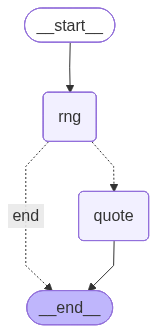

In [ ]:
flow=graph.compile()
flow

In [ ]:
a="Hello"
b="Hello"

In [ ]:
print(a is b)

True


In [ ]:
a=[1,2]
b=a
del a
print(b)

[1, 2]
